In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

conn = sqlite3.connect("../database/mutual_fund.db")

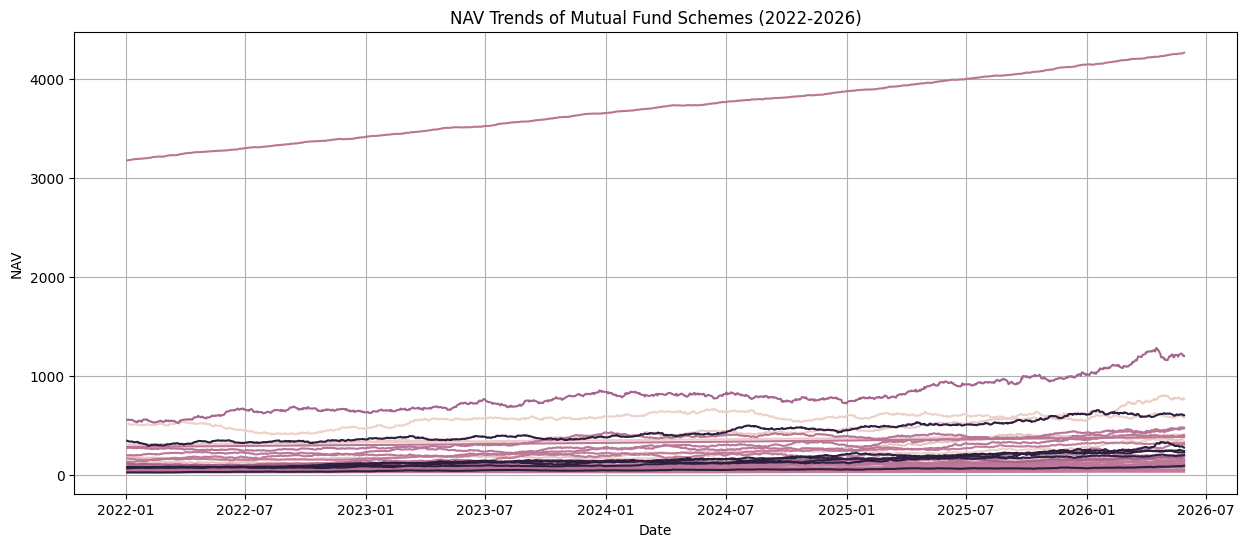

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

nav_df["date"] = pd.to_datetime(nav_df["date"])

plt.figure(figsize=(15,6))

sns.lineplot(
    data=nav_df,
    x="date",
    y="nav",
    hue="amfi_code",
    legend=False
)

plt.title("NAV Trends of Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

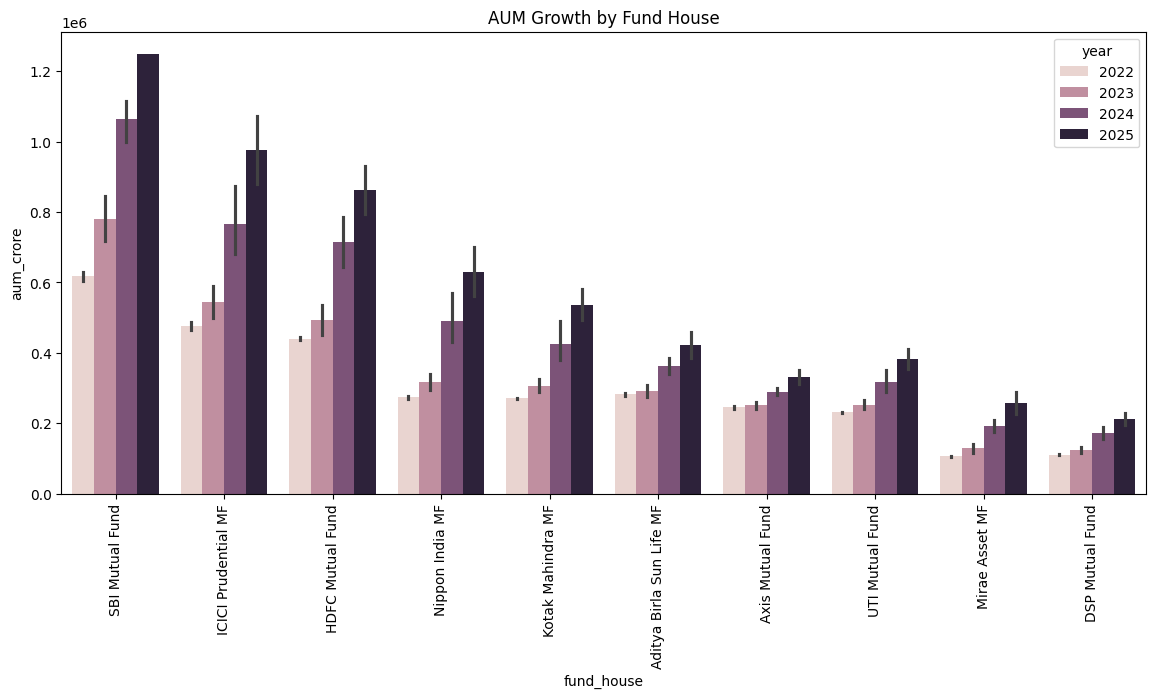

In [8]:
aum_df = pd.read_sql("""
SELECT *
FROM fact_aum
""", conn)

aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

plt.figure(figsize=(14,6))
sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.show()

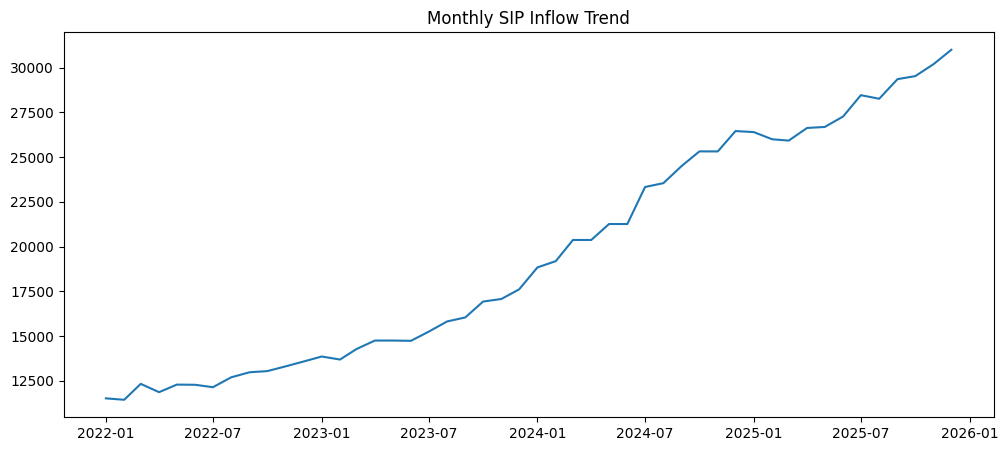

In [9]:
sip_df = pd.read_sql("""
SELECT *
FROM fact_sip
""", conn)

sip_df["month"] = pd.to_datetime(sip_df["month"])

plt.figure(figsize=(12,5))
plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.show()

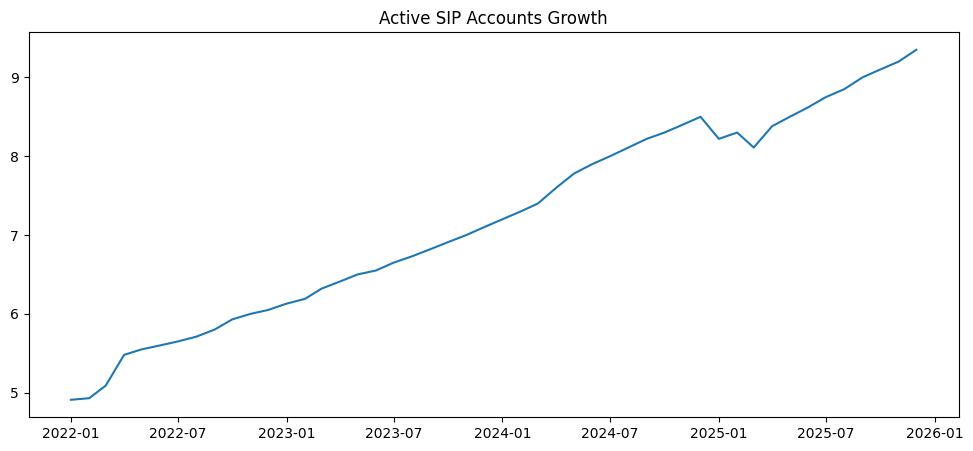

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    sip_df["month"],
    sip_df["active_sip_accounts_crore"]
)

plt.title("Active SIP Accounts Growth")
plt.show()

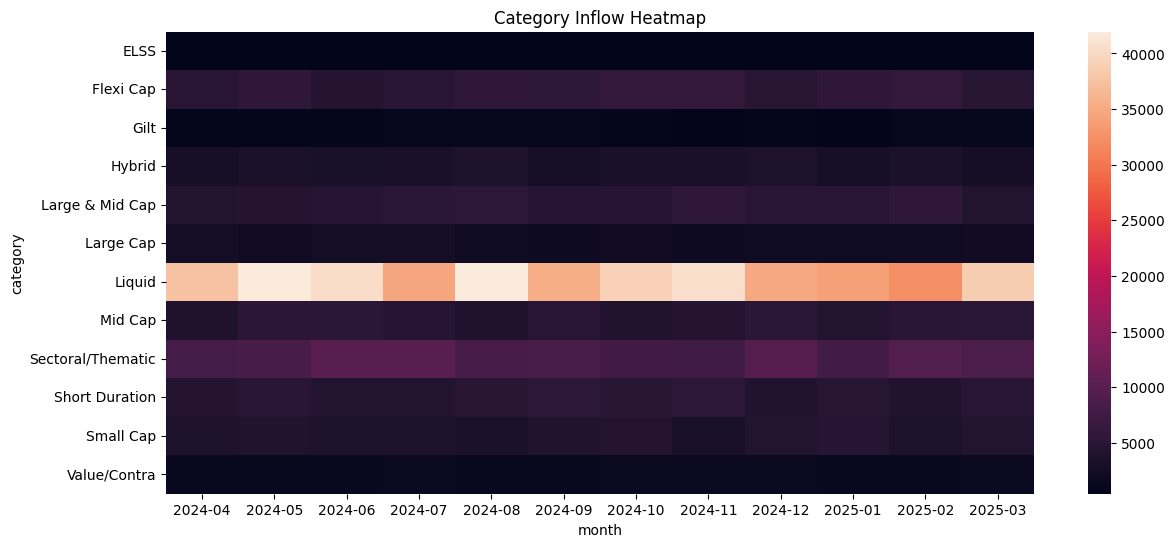

In [11]:
cat_df = pd.read_sql("""
SELECT *
FROM fact_category_inflows
""", conn)

pivot = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.show()

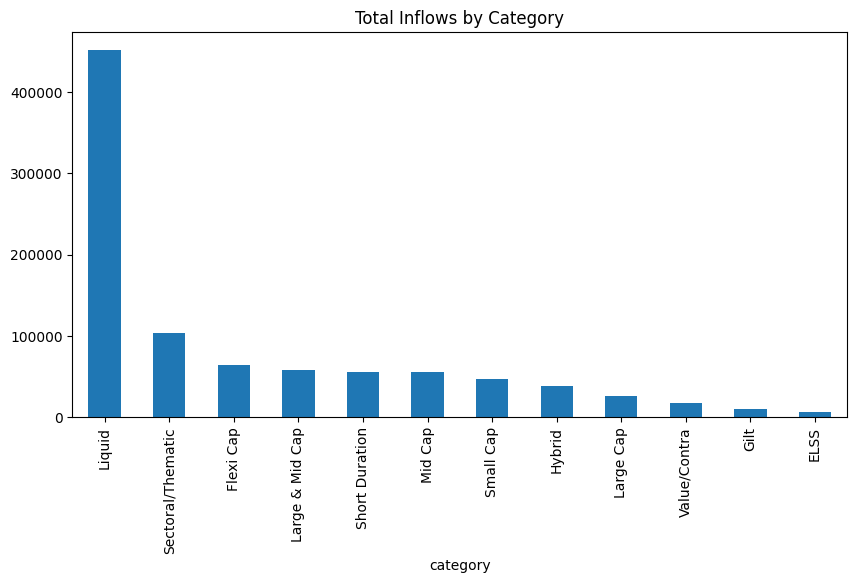

In [12]:
cat_summary = (
    cat_df.groupby("category")
          ["net_inflow_crore"]
          .sum()
          .sort_values(ascending=False)
)

cat_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Total Inflows by Category")
plt.show()

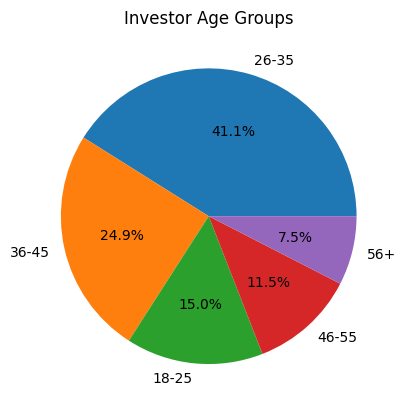

In [13]:
txn_df = pd.read_sql("""
SELECT *
FROM fact_transactions
""", conn)

txn_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Groups")
plt.show()

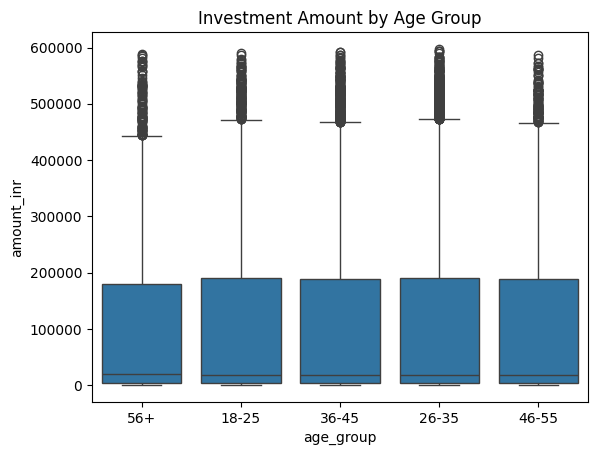

In [14]:
sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

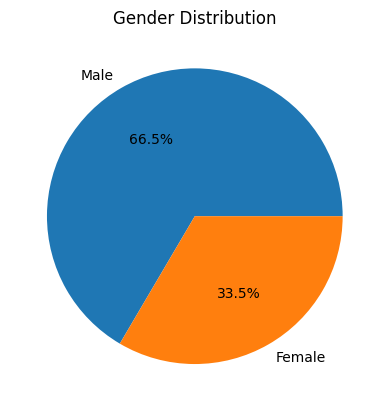

In [15]:
txn_df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

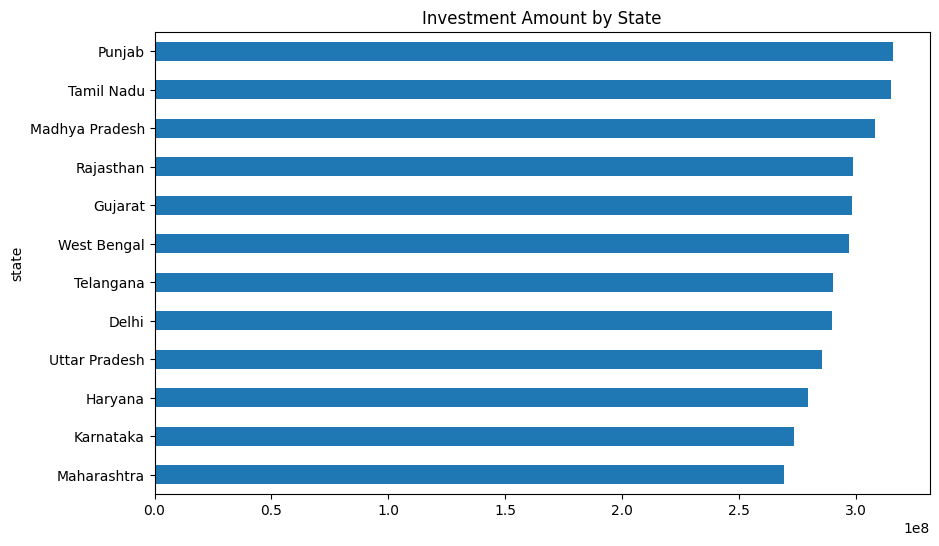

In [16]:
state_df = (
    txn_df.groupby("state")
          ["amount_inr"]
          .sum()
          .sort_values()
)

state_df.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Investment Amount by State")
plt.show()

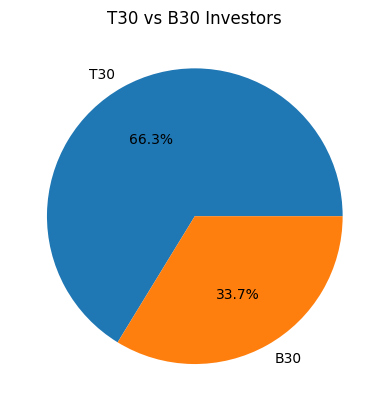

In [17]:
txn_df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")
plt.show()

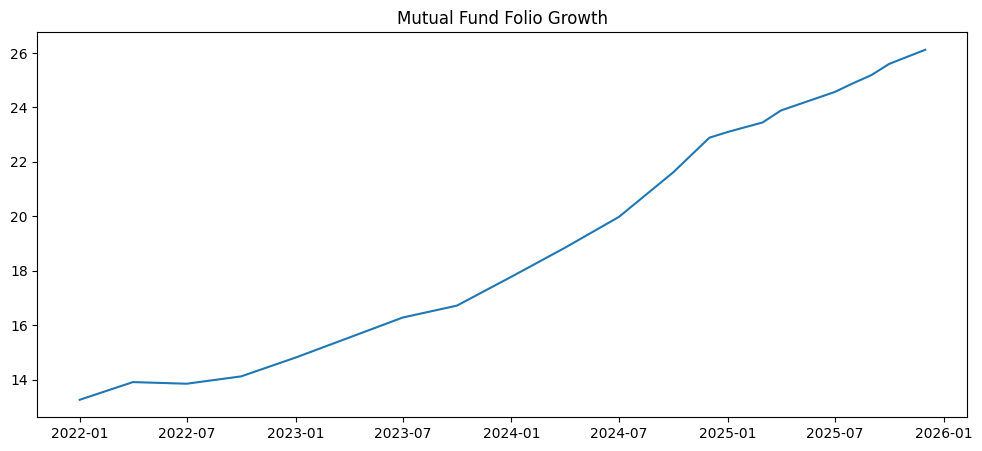

In [18]:
folio_df = pd.read_sql("""
SELECT *
FROM fact_folio
""", conn)

folio_df["month"] = pd.to_datetime(folio_df["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"]
)

plt.title("Mutual Fund Folio Growth")
plt.show()

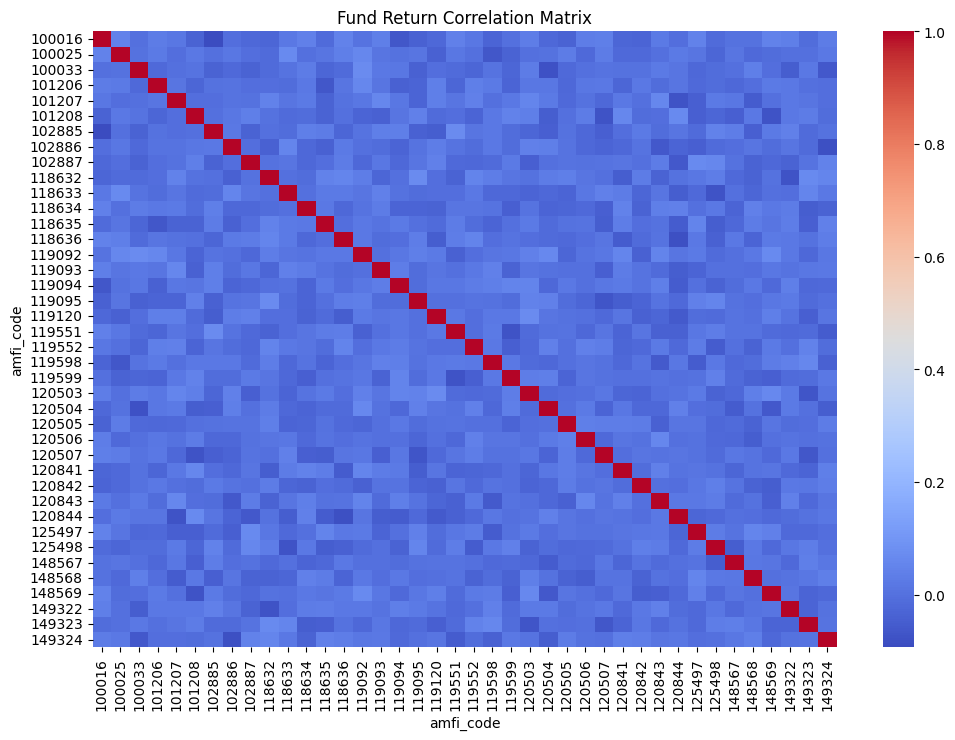

In [19]:
pivot = nav_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

plt.figure(figsize=(12,8))

sns.heatmap(
    returns.corr(),
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")
plt.show()

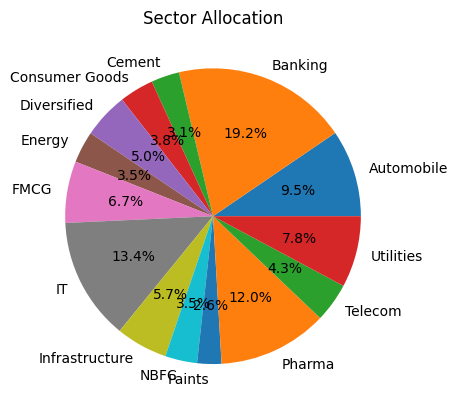

In [20]:
holdings_df = pd.read_sql("""
SELECT *
FROM fact_holdings
""", conn)

sector_df = (
    holdings_df.groupby("sector")
               ["weight_pct"]
               .sum()
)

sector_df.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")
plt.show()

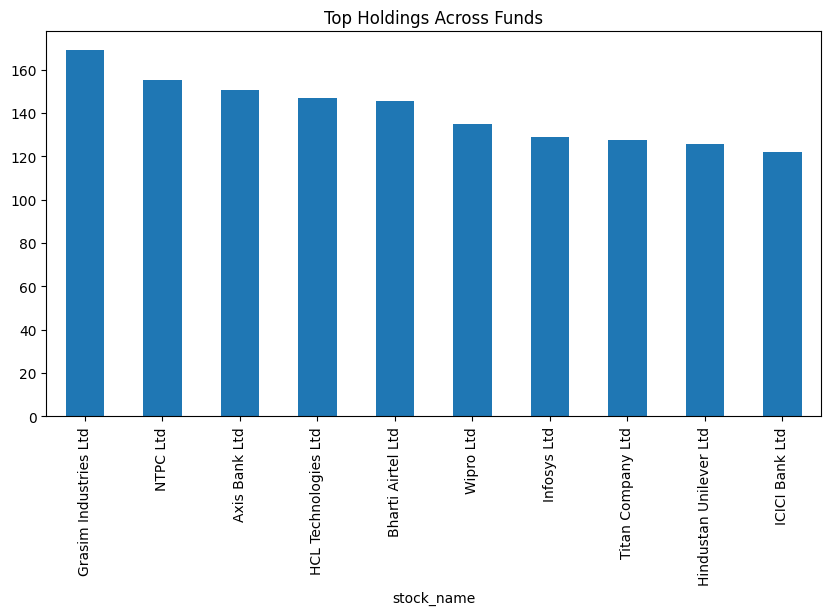

In [21]:
top_stocks = (
    holdings_df.groupby("stock_name")
               ["weight_pct"]
               .sum()
               .sort_values(ascending=False)
               .head(10)
)

top_stocks.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Holdings Across Funds")
plt.show()

In [22]:
# 10 Findings
# AUM increased steadily across major AMCs.
# SBI Mutual Fund remains the largest AMC.
# SIP inflows show strong upward momentum.
# Active SIP accounts grew significantly.
# Equity-oriented categories attracted the highest inflows.
# Investors aged 26–35 form the largest segment.
# T30 cities contribute most investments.
# Mutual fund folios nearly doubled during the period.
# Most large-cap funds exhibit high return correlation.
# Financial and IT sectors dominate fund portfolios.